# Integrating a heat capacity: how many intervals is enough?

**Skills: writing your own numerical method, log–log plots, error analysis.** Work through
*Getting started with Python and Jupyter* first if you have not already.

The enthalpy change of an ideal gas heated from $T_1$ to $T_2$ is an integral of its heat
capacity,

$$\Delta \underline{H} = \int_{T_1}^{T_2} C_P^{*}(T)\,dT,$$

a result derived in Chapter 3 and used in every chapter after it. Appendix A.II gives
$C_P^{*}$ as a cubic in $T$, so this particular integral can be done exactly, by hand.

That is precisely why it is the right place to learn numerical integration. Most of the
integrals in this book **cannot** be done by hand, and you will have to trust a numerical
answer with nothing to compare it against. Here you have the exact answer, so you can watch
a numerical method approach it, measure how fast, and learn to predict how many intervals
it will take — and then apply that judgment where no exact answer exists.

In [ ]:
# --- Colab bootstrap -------------------------------------------------------
# The axis labels below use the book's molar underbar, \underline{V}. With no LaTeX
# installed, matplotlib renders math with its own mathtext engine, which only learned
# \underline in 3.11 -- and Colab still ships 3.10. This upgrades it there, and does
# nothing at all on a machine that already has 3.11 or newer.
#
# ON COLAB THIS NEEDS A SESSION RESTART. Colab imports matplotlib as the session
# starts, so pip can replace the files on disk but not the module already loaded in
# memory: without a restart the kernel keeps running 3.10 and the labels still fail.
# One click, once per session. The cell prints the instruction when it applies.
import sys
from importlib.metadata import version

if tuple(map(int, version("matplotlib").split(".")[:2])) < (3, 11):
    !pip install -q "matplotlib>=3.11"
    if "matplotlib" in sys.modules:
        print("\n" + "=" * 72)
        print("  matplotlib was upgraded so this notebook can draw the book's notation.")
        print("  RESTART NOW:   Runtime > Restart session,   then Run all.")
        print("  Colab only, once per session. Without it the next figure will fail.")
        print("=" * 72 + "\n")
# ---------------------------------------------------------------------------

## 1. The heat capacity of nitrogen

$$C_P^{*}(T) = a + b\,T + c\,T^{2} + d\,T^{3} \qquad [\mathrm{J/(mol\,K)}],\ T\ \text{in K}$$

Note how little this function varies: from 29.2 to 32.7 J/(mol·K) across 700 kelvin. It is
very nearly a straight line, which is why the errors below turn out as
small as they do — a wilder function would need far more intervals.

Cp*(300 K) = 29.176 J/(mol K)
Cp*(1000 K) = 32.700 J/(mol K)


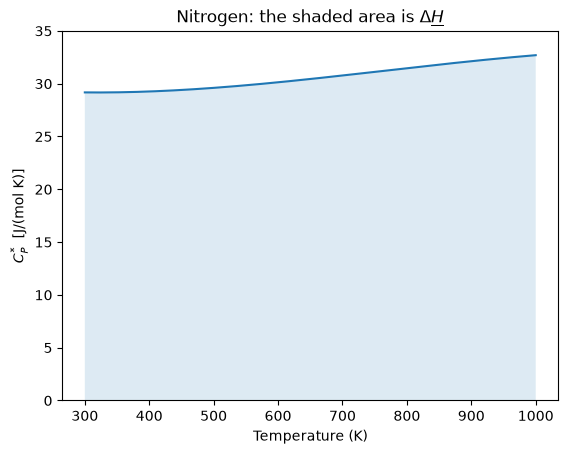

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Appendix A.II ideal-gas heat-capacity coefficients for nitrogen.
a, b, c, d = 31.15, -0.01357, 2.68e-05, -1.168e-08

R = 8.314          # J/(mol K)
T1, T2 = 300.0, 1000.0


def cp(T):
    """Ideal-gas heat capacity of nitrogen, J/(mol K). T in K."""
    return a + b*T + c*T**2 + d*T**3


print(f"Cp*({T1:.0f} K) = {cp(T1):.3f} J/(mol K)")
print(f"Cp*({T2:.0f} K) = {cp(T2):.3f} J/(mol K)")

T_plot = np.linspace(T1, T2, 200)
fig, ax = plt.subplots()
ax.plot(T_plot, cp(T_plot))
ax.fill_between(T_plot, 0, cp(T_plot), alpha=0.15)
ax.set_ylim(0, 35)
ax.set_xlabel("Temperature (K)")
ax.set_ylabel(r"$C_P^{*}$  [J/(mol K)]")
ax.set_title(r"Nitrogen: the shaded area is $\Delta\underline{H}$")
plt.show()

## 2. The exact answer

Integrate the cubic term by term:

$$\int_{T_1}^{T_2} C_P^{*}\,dT =
  a(T_2 - T_1) + \frac{b}{2}\left(T_2^{2} - T_1^{2}\right)
+ \frac{c}{3}\left(T_2^{3} - T_1^{3}\right) + \frac{d}{4}\left(T_2^{4} - T_1^{4}\right).$$

In [2]:
exact = (a * (T2 - T1)
         + b / 2 * (T2**2 - T1**2)
         + c / 3 * (T2**3 - T1**3)
         + d / 4 * (T2**4 - T1**4))

print(f"exact:  Delta H = {exact:.4f} J/mol")

# A quick sanity check: the answer must lie between the two rectangles you could
# draw, Cp(T1)*dT and Cp(T2)*dT, because Cp is increasing over this range.
print(f"bounds: {cp(T1) * (T2 - T1):.1f} < {exact:.1f} < {cp(T2) * (T2 - T1):.1f} J/mol")

exact:  Delta H = 21426.4353 J/mol
bounds: 20422.9 < 21426.4 < 22890.0 J/mol


## 3. The trapezoidal rule, written out

Now pretend you did not have the polynomial. Split the temperature range into $n$ equal
intervals of width $h = (T_2 - T_1)/n$, approximate the curve by a straight line across each
one, and add up the areas of the trapezoids. Every interior point gets counted twice — once
by the trapezoid on each side — and the two ends once, which is where the halves come from:

$$\int_{T_1}^{T_2} f\,dT \approx h\left[\tfrac{1}{2}f_0 + f_1 + f_2 + \cdots + f_{n-1}
  + \tfrac{1}{2}f_n\right].$$

Write it with a loop first, exactly as the formula reads. Do it once by hand:
`for` loops are the version you can check line by line against the mathematics.

In [3]:
def trapezoid_loop(f, lo, hi, n):
    """Trapezoidal rule with n intervals, written as the formula reads."""
    h = (hi - lo) / n
    total = 0.5 * f(lo) + 0.5 * f(hi)
    for i in range(1, n):
        total += f(lo + i * h)
    return h * total


print(f"n =  4 : {trapezoid_loop(cp, T1, T2, 4):.4f} J/mol")
print(f"n = 32 : {trapezoid_loop(cp, T1, T2, 32):.4f} J/mol")
print(f"exact  : {exact:.4f} J/mol")

n =  4 : 21440.8127 J/mol
n = 32 : 21426.6600 J/mol
exact  : 21426.4353 J/mol


The same thing without the loop, since `cp` already accepts an array. Both must give
identical answers — if they do not, one of them is wrong, and that is exactly the kind of
disagreement you want to discover on a problem whose answer you know.

(NumPy has `np.trapezoid` built in and you should use it in real work. Writing it out once
is how you learn what it is doing, and why its error behaves as it does.)

In [4]:
def trapezoid(f, lo, hi, n):
    """Trapezoidal rule with n intervals, using array arithmetic."""
    x = np.linspace(lo, hi, n + 1)
    y = f(x)
    h = (hi - lo) / n
    return h * (0.5 * y[0] + y[1:-1].sum() + 0.5 * y[-1])


for n in (4, 32):
    print(f"n = {n:2d}:  loop {trapezoid_loop(cp, T1, T2, n):.6f}"
          f"   array {trapezoid(cp, T1, T2, n):.6f}")

print("\nagree:", np.allclose(trapezoid_loop(cp, T1, T2, 32), trapezoid(cp, T1, T2, 32)))

n =  4:  loop 21440.812750   array 21440.812750
n = 32:  loop 21426.659980   array 21426.659980

agree: True


## 4. Does it converge, and how fast?

One number is not evidence of convergence. Halve the interval width repeatedly and watch what the error
does — that is the only way to know whether an answer you cannot check is converged.

In [5]:
n_values = np.array([2, 4, 8, 16, 32, 64, 128, 256])
errors = np.array([trapezoid(cp, T1, T2, n) - exact for n in n_values])

print(f"{'n':>5}{'trapezoid':>14}{'error':>12}{'ratio':>9}")
for i, (n, err) in enumerate(zip(n_values, errors)):
    ratio = f"{errors[i-1] / err:8.2f}" if i else " " * 8
    print(f"{n:5d}{trapezoid(cp, T1, T2, n):14.4f}{err:12.4f}{ratio}")

    n     trapezoid       error    ratio
    2    21483.9450     57.5097        
    4    21440.8127     14.3774    4.00
    8    21430.0297      3.5944    4.00
   16    21427.3339      0.8986    4.00
   32    21426.6600      0.2246    4.00
   64    21426.4915      0.0562    4.00
  128    21426.4494      0.0140    4.00
  256    21426.4388      0.0035    4.00


**Every doubling of $n$ divides the error by four.** That is the fingerprint of a method
whose error goes as $h^{2}$: halve the width, quarter the error. On logarithmic axes an
error that behaves like $n^{-2}$ plots as a straight line of slope $-2$, and that slope
should be measured rather than assumed — a fitted slope of $-1$ or $-4$ would mean you had
implemented a different method from the one you thought.

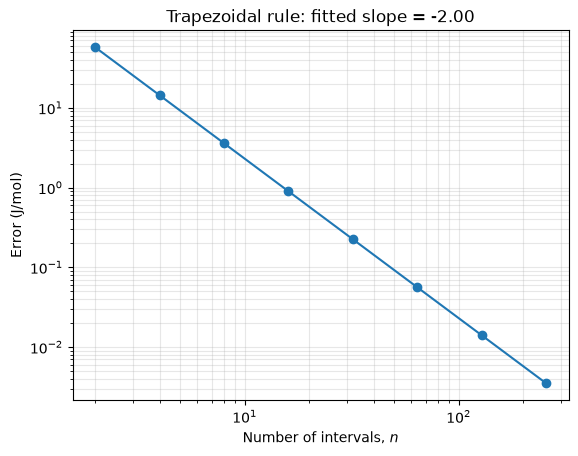

fitted slope = -2.0000   (the trapezoidal rule is O(h^2), so -2 is expected)


In [6]:
slope, intercept = np.polyfit(np.log(n_values), np.log(errors), 1)

fig, ax = plt.subplots()
ax.loglog(n_values, errors, "o-")
ax.set_xlabel("Number of intervals, $n$")
ax.set_ylabel("Error (J/mol)")
ax.set_title(f"Trapezoidal rule: fitted slope = {slope:.2f}")
ax.grid(True, which="both", alpha=0.3)
plt.show()

print(f"fitted slope = {slope:.4f}   (the trapezoidal rule is O(h^2), so -2 is expected)")

So you can now answer a question that had no answer before: **how many intervals do you
need?** Ask for the error you are willing to accept and step up until you have it.

In [7]:
tolerance = 0.1        # J/mol

n = 2
while abs(trapezoid(cp, T1, T2, n) - exact) > tolerance:
    n += 1

print(f"{n} intervals give an error of "
      f"{trapezoid(cp, T1, T2, n) - exact:.4f} J/mol, within {tolerance} J/mol.")
print(f"\nFor scale: 0.1 J/mol out of {exact:.0f} J/mol is "
      f"{100 * tolerance / exact:.5f}% -- far below the accuracy of the "
      f"heat-capacity correlation itself.")

48 intervals give an error of 0.0998 J/mol, within 0.1 J/mol.

For scale: 0.1 J/mol out of 21426 J/mol is 0.00047% -- far below the accuracy of the heat-capacity correlation itself.


That last line matters more than the convergence study. Forty-eight intervals get you
within 0.1 J/mol of the exact integral of *this polynomial* — but the polynomial is itself a
fit to measured heat capacities, good to a few tenths of a J/(mol·K). **Converging the
arithmetic past the accuracy of the data does not improve the answer.** Knowing where to stop is the
practical half of error analysis.

## 5. The internal energy as well

For an ideal gas $C_V^{*} = C_P^{*} - R$ (Chapter 3), so the internal-energy change over
the same temperature rise is smaller by exactly $R\,\Delta T$ — the work the gas does
pushing its surroundings back as it expands at constant pressure.

For five moles of nitrogen heated from 300 to 1000 K:

In [8]:
n_moles = 5.0

delta_H = exact                                   # J/mol
delta_U = exact - R * (T2 - T1)                   # J/mol

print(f"per mole:  Delta H = {delta_H:8.1f} J/mol    Delta U = {delta_U:8.1f} J/mol")
print(f"{n_moles:.0f} mol:     Delta H = {n_moles * delta_H / 1000:8.2f} kJ"
      f"       Delta U = {n_moles * delta_U / 1000:8.2f} kJ")
print(f"\ndifference = R*(T2-T1)*n = {n_moles * R * (T2 - T1) / 1000:.2f} kJ")

per mole:  Delta H =  21426.4 J/mol    Delta U =  15606.6 J/mol
5 mol:     Delta H =   107.13 kJ       Delta U =    78.03 kJ

difference = R*(T2-T1)*n = 29.10 kJ


## What this notebook shows

- **The trapezoidal rule is four lines of code**, and writing it as a loop once tells you
  exactly what it does.
- **Its error falls as $h^{2}$:** each doubling of $n$ quarters the error, which is a slope
  of $-2$ on log–log axes. Measure that slope — it is a check on your implementation, not
  a decoration.
- **Convergence is something you demonstrate, not assume.** One numerical answer cannot show
  convergence; a sequence of them can.
- **Stop refining when the arithmetic is better than the data.** 48 intervals reach
  0.1 J/mol here, which is already far inside the uncertainty of the Appendix A.II
  correlation itself.
- Check a new routine against a known answer, and check two implementations against each
  other. This notebook did both, on purpose.

## Your turn

1. Repeat §4 with the **midpoint** rule — the same intervals, but the height taken at the
   center of each rather than averaged over its ends. Is the fitted slope different? Is the
   error larger or smaller than the trapezoidal rule's at the same $n$?
2. Integrate $C_P^{*}$ from 300 to 400 K instead of 300 to 1000 K, and find how many
   intervals it takes to reach 0.1 J/mol. Fewer or more? Explain the answer in terms of $h$.
3. Replace `cp` with a function that varies far more sharply over the range — say
   $\sin(T/20)$ — and repeat the convergence table. The slope should still be $-2$. Is the
   error at $n = 8$ still small?
4. Use `np.trapezoid(cp(x), x)` for one of the cases above and confirm it agrees with your
   own routine. If it does not, which one do you suspect, and how would you find out?